# Act 1 — "How Brackets Die"

**A forensic analysis of March Madness bracket failure since 1985.**

Every March, tens of millions of Americans fill out tournament brackets. Nearly all of them are dead by the Sweet 16. This act investigates *why* — which rounds, which seeds, and which matchups destroy the most brackets, and how chaos has evolved over four decades of tournament play.

---

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.data_loader import MarchMadnessData
from src.upset_analysis import (
    upset_rate_by_round,
    upset_rate_by_matchup,
    upset_rate_by_year,
    chaos_index,
    seed_advancement_rates,
    trap_seeds,
    ROUND_NAMES,
)

# Plotting defaults
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"

COLORS = {
    "primary": "#1a1a2e",
    "accent": "#e94560",
    "secondary": "#0f3460",
    "highlight": "#f5a623",
    "bg": "#f8f9fa",
}

FIGURES_DIR = "../outputs/figures"

In [2]:
# Load data
loader = MarchMadnessData("../data/raw")
games = loader.get_tourney_results()

print(f"Loaded {len(games)} tournament games from {games['Season'].min()} to {games['Season'].max()}")
print(f"Seasons: {games['Season'].nunique()}")
games.head()

Loaded 2518 tournament games from 1985 to 2024
Seasons: 39


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,Round,WSeed,WSeedNum,WRegion,LSeed,LSeedNum,LRegion,WTeamName,LTeamName,ScoreDiff,Upset
0,1985,136,1116,63,1234,54,N,0,1,X09,9,X,X08,8,X,Arkansas,Iowa,9,True
1,1985,136,1120,59,1345,58,N,0,1,Z11,11,Z,Z06,6,Z,Auburn,Purdue,1,True
2,1985,136,1207,68,1250,43,N,0,1,W01,1,W,W16,16,W,Georgetown,Lehigh,25,False
3,1985,136,1229,58,1425,55,N,0,1,Y09,9,Y,Y08,8,Y,Illinois St,USC,3,True
4,1985,136,1242,49,1325,38,N,0,1,Z03,3,Z,Z14,14,Z,Kansas,Ohio,11,False


---
## 1. Which Round Kills the Most Brackets?

Conventional wisdom says the first round is chaos. But how does upset frequency *actually* distribute across rounds?

In [3]:
round_upsets = upset_rate_by_round(games)
round_upsets

,Round,TotalGames,Upsets,UpsetRate,RoundName
0,1,1247,326,0.261427,Round of 64
1,2,624,180,0.288462,Round of 32
2,3,312,95,0.304487,Sweet 16
3,4,156,68,0.435897,Elite 8
4,5,78,19,0.243590,Final Four
5,6,39,7,0.179487,Championship


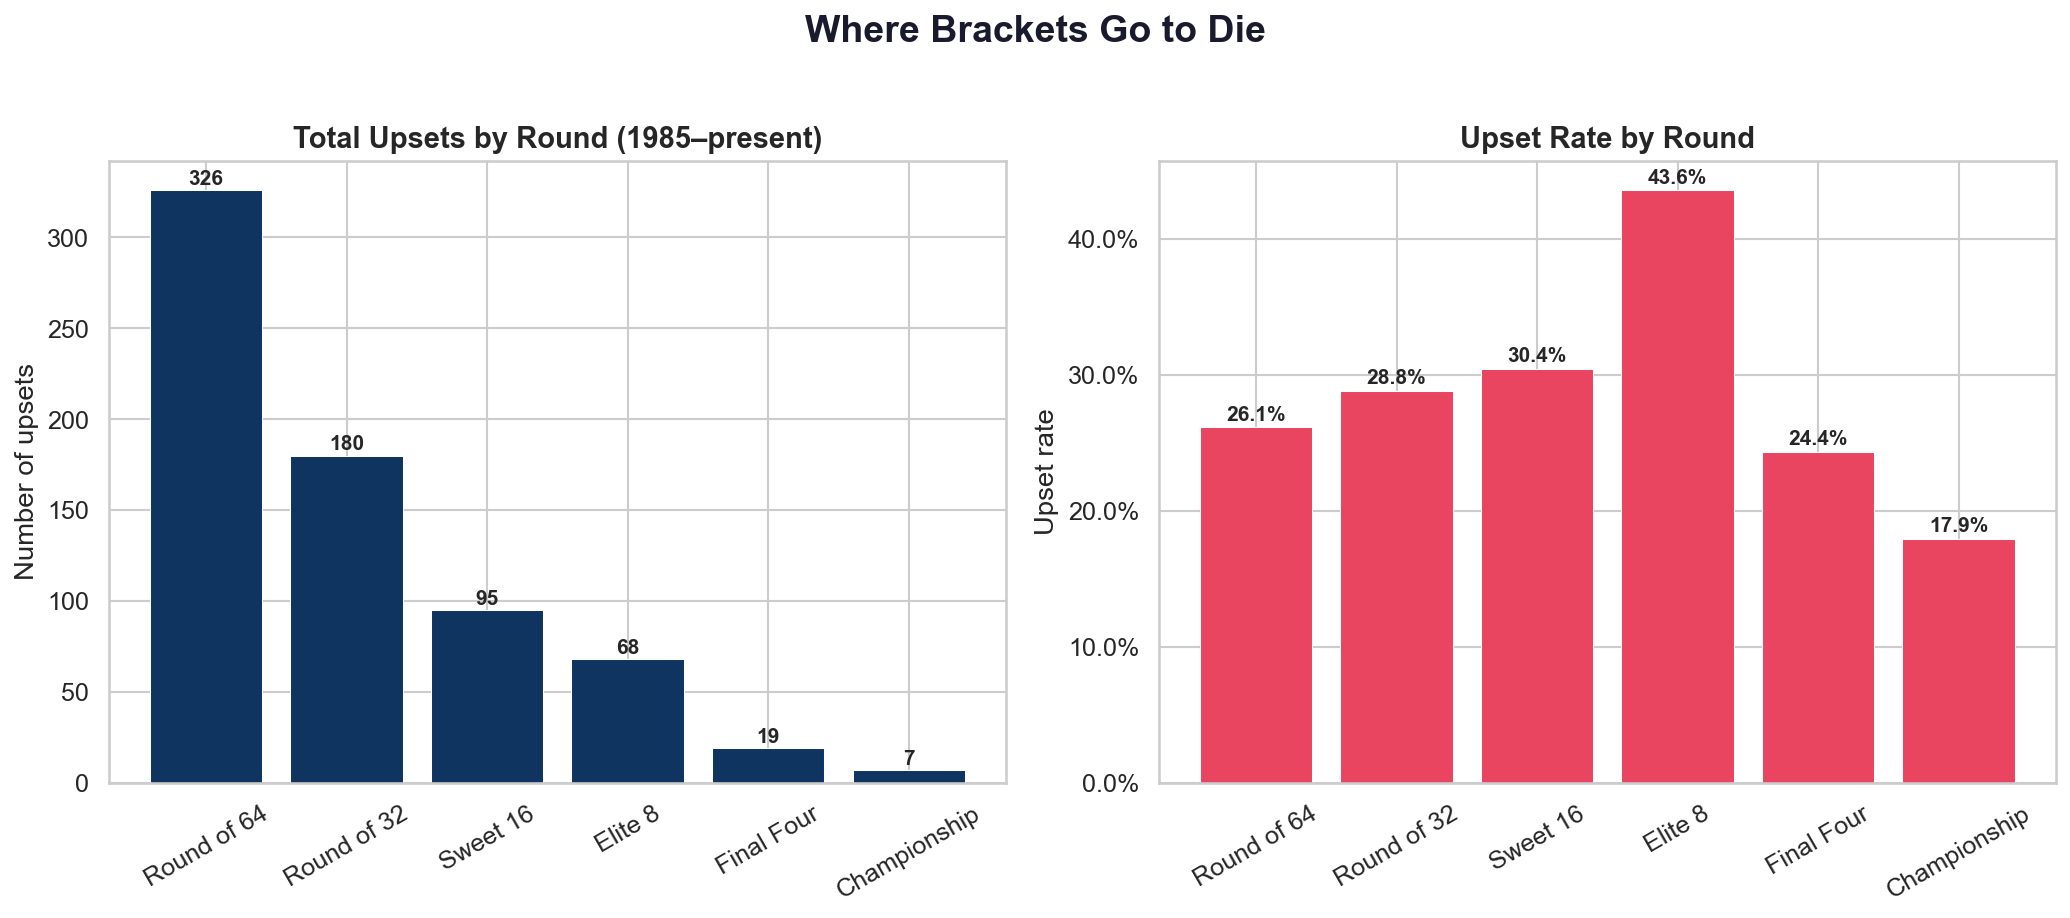

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: absolute upset count by round
ax = axes[0]
bars = ax.bar(
    round_upsets["RoundName"],
    round_upsets["Upsets"],
    color=COLORS["secondary"],
    edgecolor="white",
    linewidth=0.5,
)
# Label each bar with count
for bar, val in zip(bars, round_upsets["Upsets"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            str(int(val)), ha="center", fontsize=10, fontweight="bold")

ax.set_title("Total Upsets by Round (1985–present)", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of upsets")
ax.tick_params(axis="x", rotation=30)

# Right: upset rate by round
ax = axes[1]
rate_bars = ax.bar(
    round_upsets["RoundName"],
    round_upsets["UpsetRate"],
    color=COLORS["accent"],
    edgecolor="white",
    linewidth=0.5,
)
# Label each bar with percentage
for bar, val in zip(rate_bars, round_upsets["UpsetRate"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val:.1%}", ha="center", fontsize=10, fontweight="bold")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Upset Rate by Round", fontsize=14, fontweight="bold")
ax.set_ylabel("Upset rate")
ax.tick_params(axis="x", rotation=30)

fig.suptitle(
    "Where Brackets Go to Die",
    fontsize=18,
    fontweight="bold",
    y=1.02,
    color=COLORS["primary"],
)
plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/act1_upset_rate_by_round.png")
plt.show()

**Takeaway:** The Round of 64 produces the most raw upsets (326 since 1985) simply because it has the most games. But the *rate* tells a different story: the **Elite 8 is the true chaos round at ~44%** — by that point, the surviving underdogs are battle-tested and the matchups are closer. The Final Four and Championship see lower upset rates because top seeds have largely consolidated.

---
## 2. Trap Picks: Which First-Round Matchups Betray the Most Brackets?

Everyone picks the #1 seed. But some mid-tier matchups — like 5-vs-12 — are historically much more volatile than their seed numbers suggest.

In [5]:
matchup_rates = upset_rate_by_matchup(games)
matchup_rates

,HighSeed,LowSeed,Games,Upsets,UpsetRate,Matchup
0,1,16,156,2,0.012821,#1 vs #16
1,2,15,156,11,0.070513,#2 vs #15
2,3,14,156,23,0.147436,#3 vs #14
3,4,13,156,33,0.211538,#4 vs #13
4,5,12,156,55,0.352564,#5 vs #12
5,6,11,156,61,0.391026,#6 vs #11
6,7,10,155,60,0.387097,#7 vs #10
7,8,9,156,81,0.519231,#8 vs #9


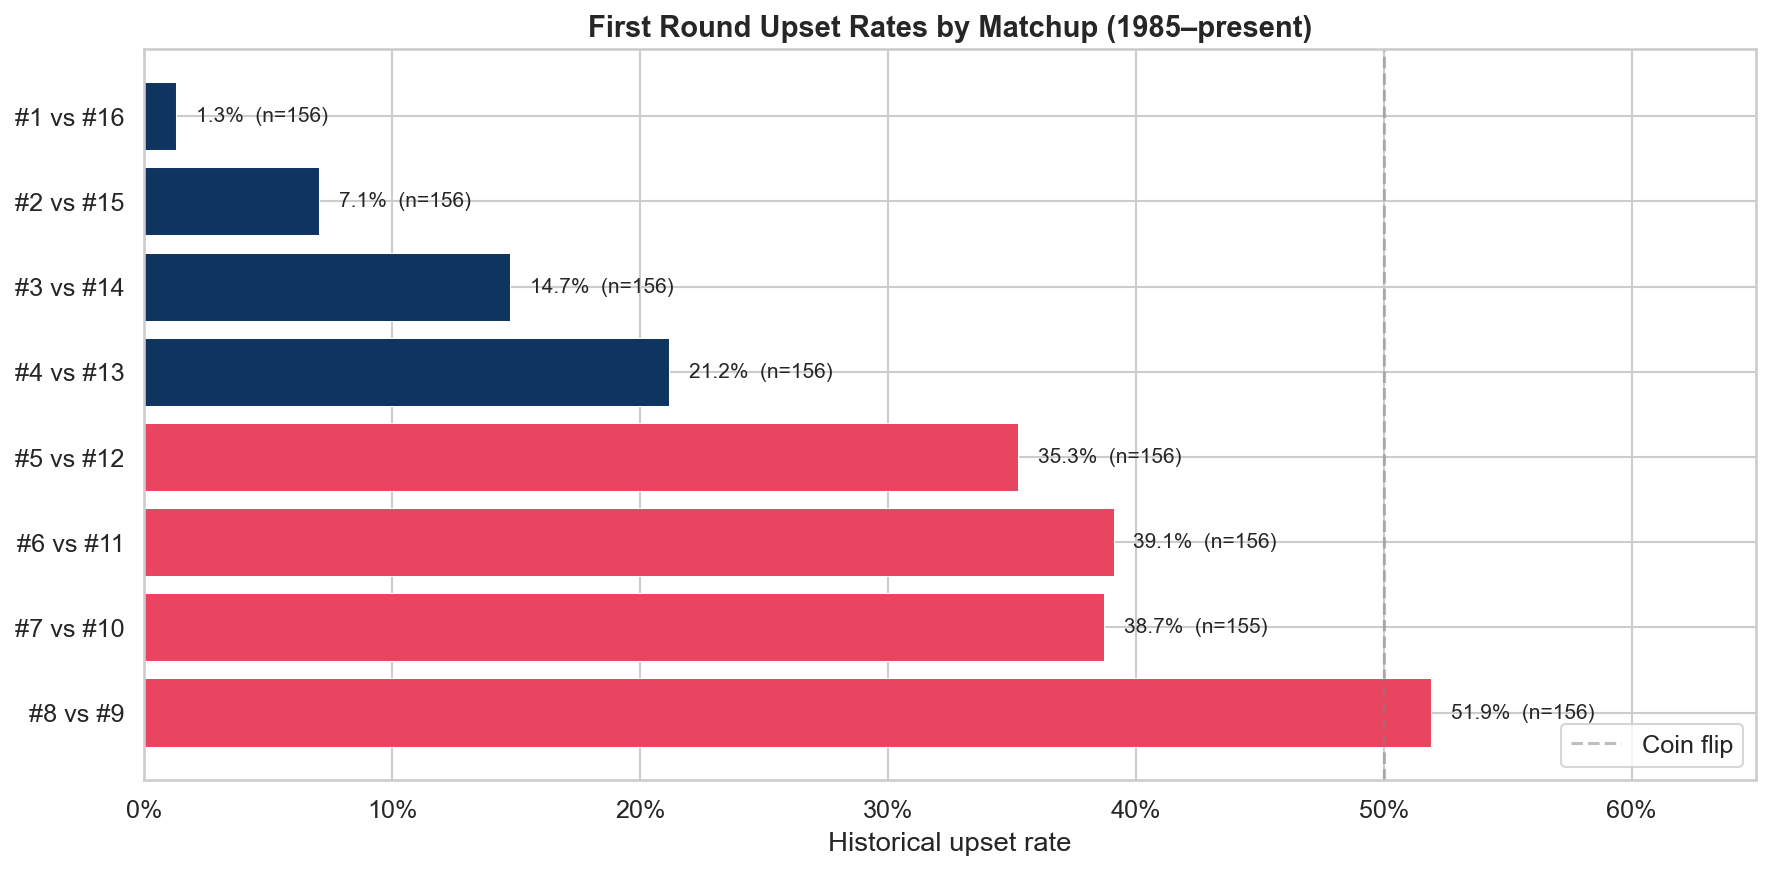

In [6]:
# Only show the 8 standard seed matchups (filter out same-seed play-in artifacts)
standard = matchup_rates[matchup_rates["HighSeed"] != matchup_rates["LowSeed"]].copy()

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(
    standard["Matchup"],
    standard["UpsetRate"],
    color=[COLORS["accent"] if r > 0.25 else COLORS["secondary"] for r in standard["UpsetRate"]],
    edgecolor="white",
    linewidth=0.5,
)

# Add percentage labels
for bar, rate, n in zip(bars, standard["UpsetRate"], standard["Games"]):
    ax.text(
        bar.get_width() + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{rate:.1%}  (n={n})",
        va="center",
        fontsize=10,
    )

ax.set_xlim(0, 0.65)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Historical upset rate")
ax.set_title(
    "First Round Upset Rates by Matchup (1985–present)",
    fontsize=14,
    fontweight="bold",
)
ax.invert_yaxis()

# Add a reference line at 50%
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5, label="Coin flip")
ax.legend(loc="lower right")

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/act1_r64_matchup_upset_rates.png")
plt.show()

**Takeaway:** The **8-vs-9 matchup is essentially a coin flip** (52% upset rate) — picking the 8-seed is barely better than random. The **5-vs-12** (35%) and **6-vs-11** (39%) are the classic "trap picks" — seeds that casual fans over-trust. Meanwhile, #1 seeds have only lost twice in 156 R64 games (UMBC over Virginia in 2018, FDU over Purdue in 2023).

---
## 3. Trap Seeds: Who Underperforms Their Seed the Most?

Beyond individual matchups, which seed *numbers* most underperform relative to what you'd naively expect?

In [7]:
traps = trap_seeds(games)
traps

,SeedNum,Games,FavoredWins,ActualWinRate,ExpectedWinRate,TrapScore
0,5,156,101,0.647436,0.705882,0.058446
1,8,156,75,0.480769,0.529412,0.048643
2,6,156,95,0.608974,0.647059,0.038084
3,4,156,123,0.788462,0.764706,-0.023756
4,7,155,95,0.612903,0.588235,-0.024668
5,3,156,133,0.852564,0.823529,-0.029035
6,1,156,154,0.987179,0.941176,-0.046003
7,2,156,145,0.929487,0.882353,-0.047134


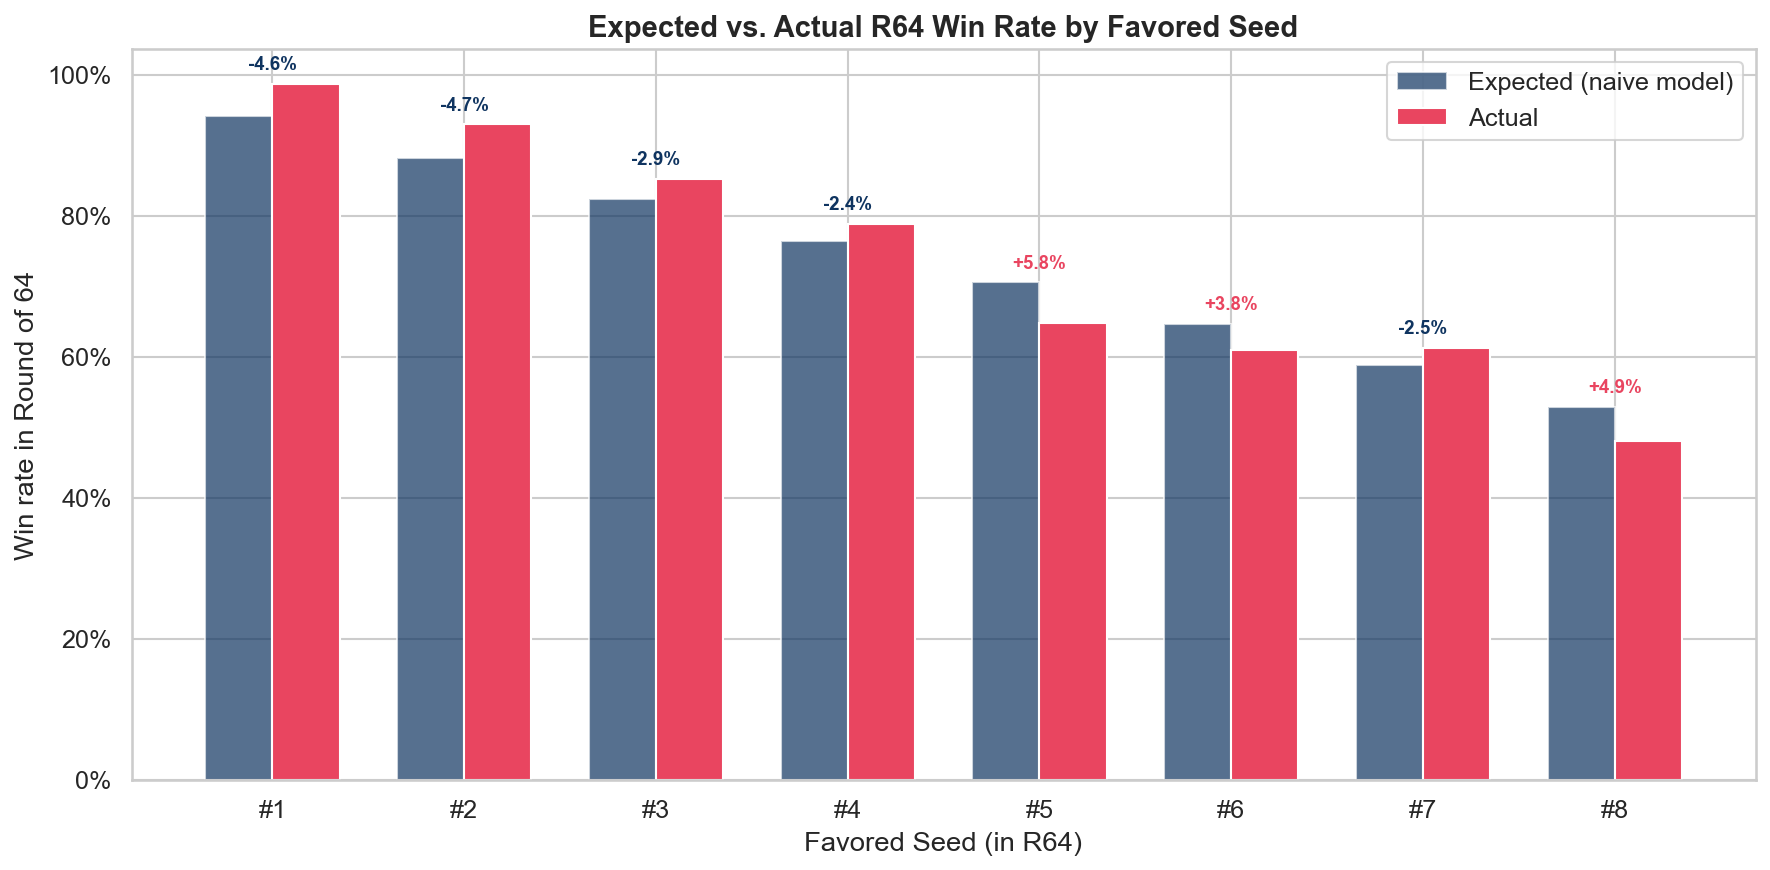

In [8]:
# Sort by seed number for readable chart, filter to seeds 1-8 (the favored seeds)
traps_sorted = traps[traps["SeedNum"] <= 8].sort_values("SeedNum")

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(traps_sorted))
width = 0.35

ax.bar(x - width / 2, traps_sorted["ExpectedWinRate"], width,
       label="Expected (naive model)", color=COLORS["secondary"], alpha=0.7)
ax.bar(x + width / 2, traps_sorted["ActualWinRate"], width,
       label="Actual", color=COLORS["accent"])

ax.set_xticks(x)
ax.set_xticklabels([f"#{int(s)}" for s in traps_sorted["SeedNum"]])
ax.set_xlabel("Favored Seed (in R64)")
ax.set_ylabel("Win rate in Round of 64")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
ax.set_title(
    "Expected vs. Actual R64 Win Rate by Favored Seed",
    fontsize=14,
    fontweight="bold",
)

# Annotate trap score
for i, (_, row) in enumerate(traps_sorted.iterrows()):
    color = COLORS["accent"] if row["TrapScore"] > 0 else COLORS["secondary"]
    sign = "+" if row["TrapScore"] > 0 else ""
    ax.text(
        i, max(row["ExpectedWinRate"], row["ActualWinRate"]) + 0.02,
        f"{sign}{row['TrapScore']:.1%}",
        ha="center", fontsize=9, color=color, fontweight="bold",
    )

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/act1_trap_seeds.png")
plt.show()

---
## 4. Has March Gotten Madder? Upset Trends Over Time

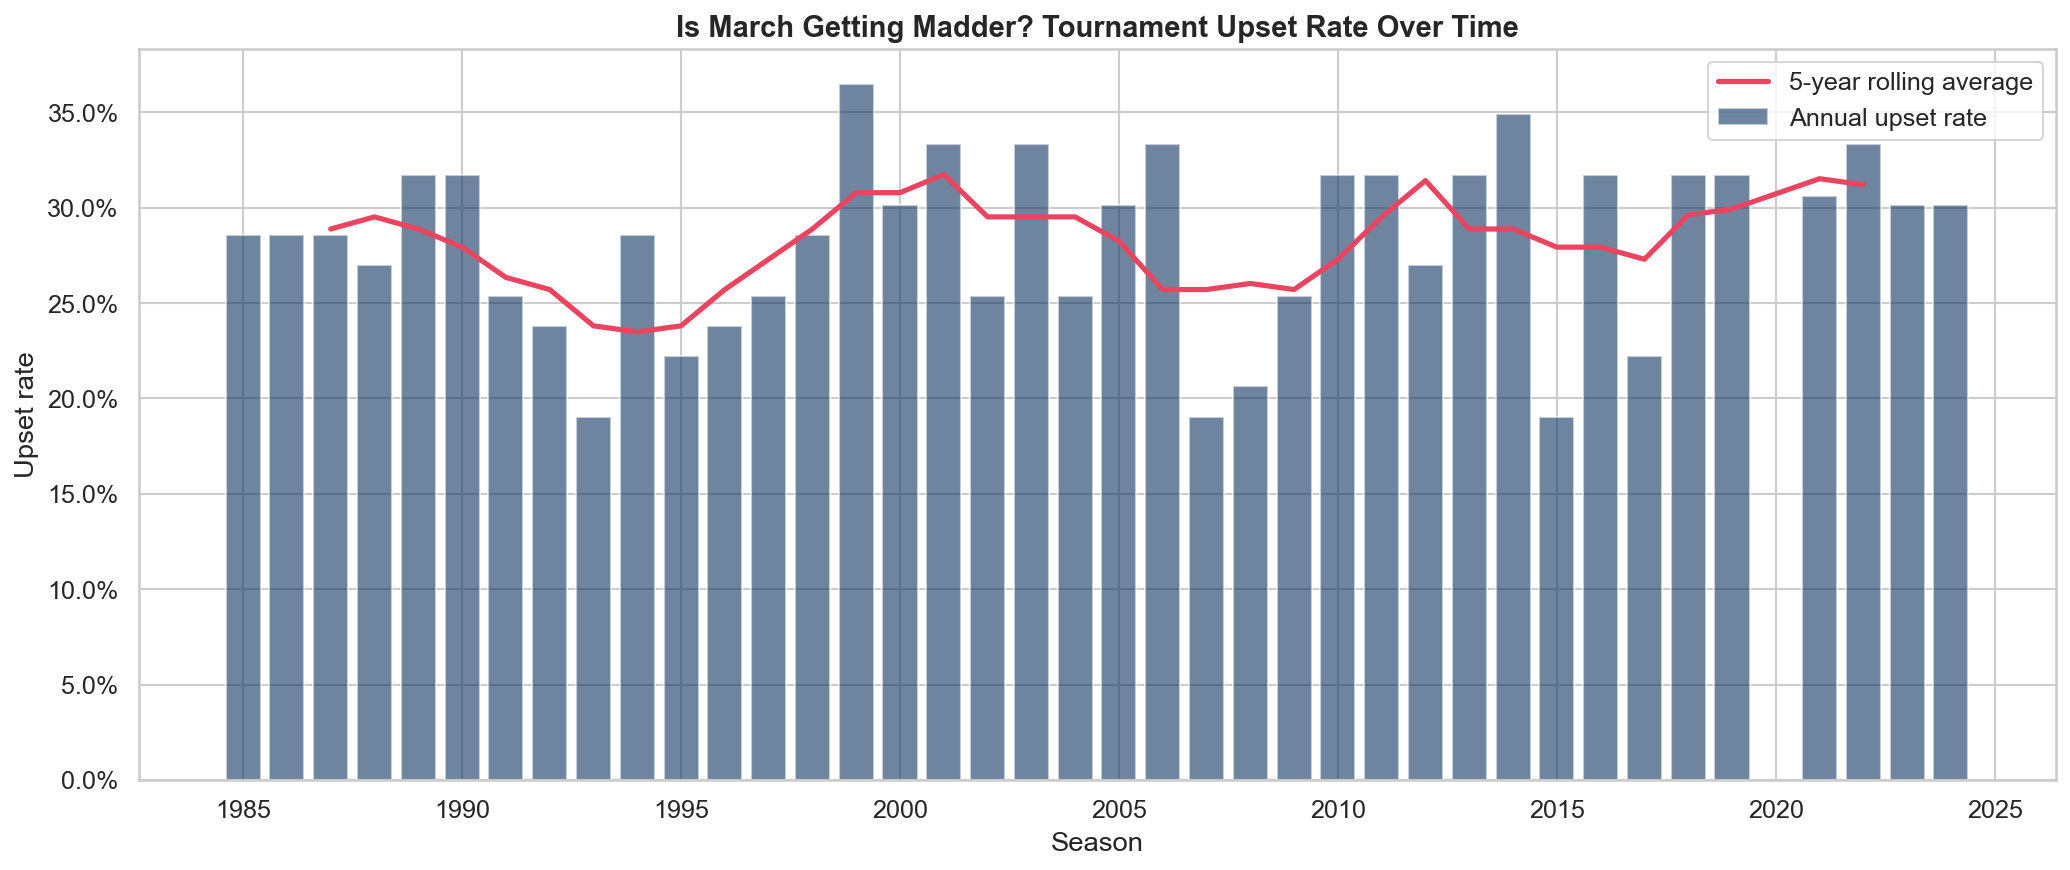

In [9]:
yearly = upset_rate_by_year(games)

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(
    yearly["Season"],
    yearly["UpsetRate"],
    color=COLORS["secondary"],
    alpha=0.6,
    label="Annual upset rate",
)

# Rolling average
yearly_sorted = yearly.sort_values("Season")
rolling = yearly_sorted["UpsetRate"].rolling(5, center=True).mean()
ax.plot(
    yearly_sorted["Season"],
    rolling,
    color=COLORS["accent"],
    linewidth=2.5,
    label="5-year rolling average",
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Season")
ax.set_ylabel("Upset rate")
ax.set_title(
    "Is March Getting Madder? Tournament Upset Rate Over Time",
    fontsize=14,
    fontweight="bold",
)
ax.legend()

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/act1_upset_trend.png")
plt.show()

---
## 5. The Chaos Rankings: Most Chaotic Tournaments Ever

Not all upsets are created equal. A 9-seed beating an 8-seed barely registers. A 16-seed slaying a 1 is a seismic event. Our chaos index weights upsets by seed gap *and* round — late-round upsets wreck far more brackets.

In [10]:
chaos = chaos_index(games)
chaos.head(15)

,Season,ChaosScore,Upsets,TotalGames,BiggestUpset
0,1985,495,18,63,#8 Villanova over #1 Georgetown (Championship)
1,2014,428,22,63,#7 Connecticut over #1 Florida (Final Four)
2,1988,357,17,63,#6 Kansas over #1 Oklahoma (Championship)
3,2022,316,21,63,#8 North Carolina over #2 Duke (Final Four)
4,2011,295,20,63,#11 VCU over #1 Kansas (Elite 8)
5,1986,288,18,63,#11 LSU over #1 Kentucky (Elite 8)
6,2006,285,21,63,#11 George Mason over #1 Connecticut (Elite 8)
7,2021,276,19,62,#11 UCLA over #1 Michigan (Elite 8)
8,1997,247,16,63,#4 Arizona over #1 Kentucky (Championship)
9,2023,231,19,63,#9 FL Atlantic over #3 Kansas St (Elite 8)


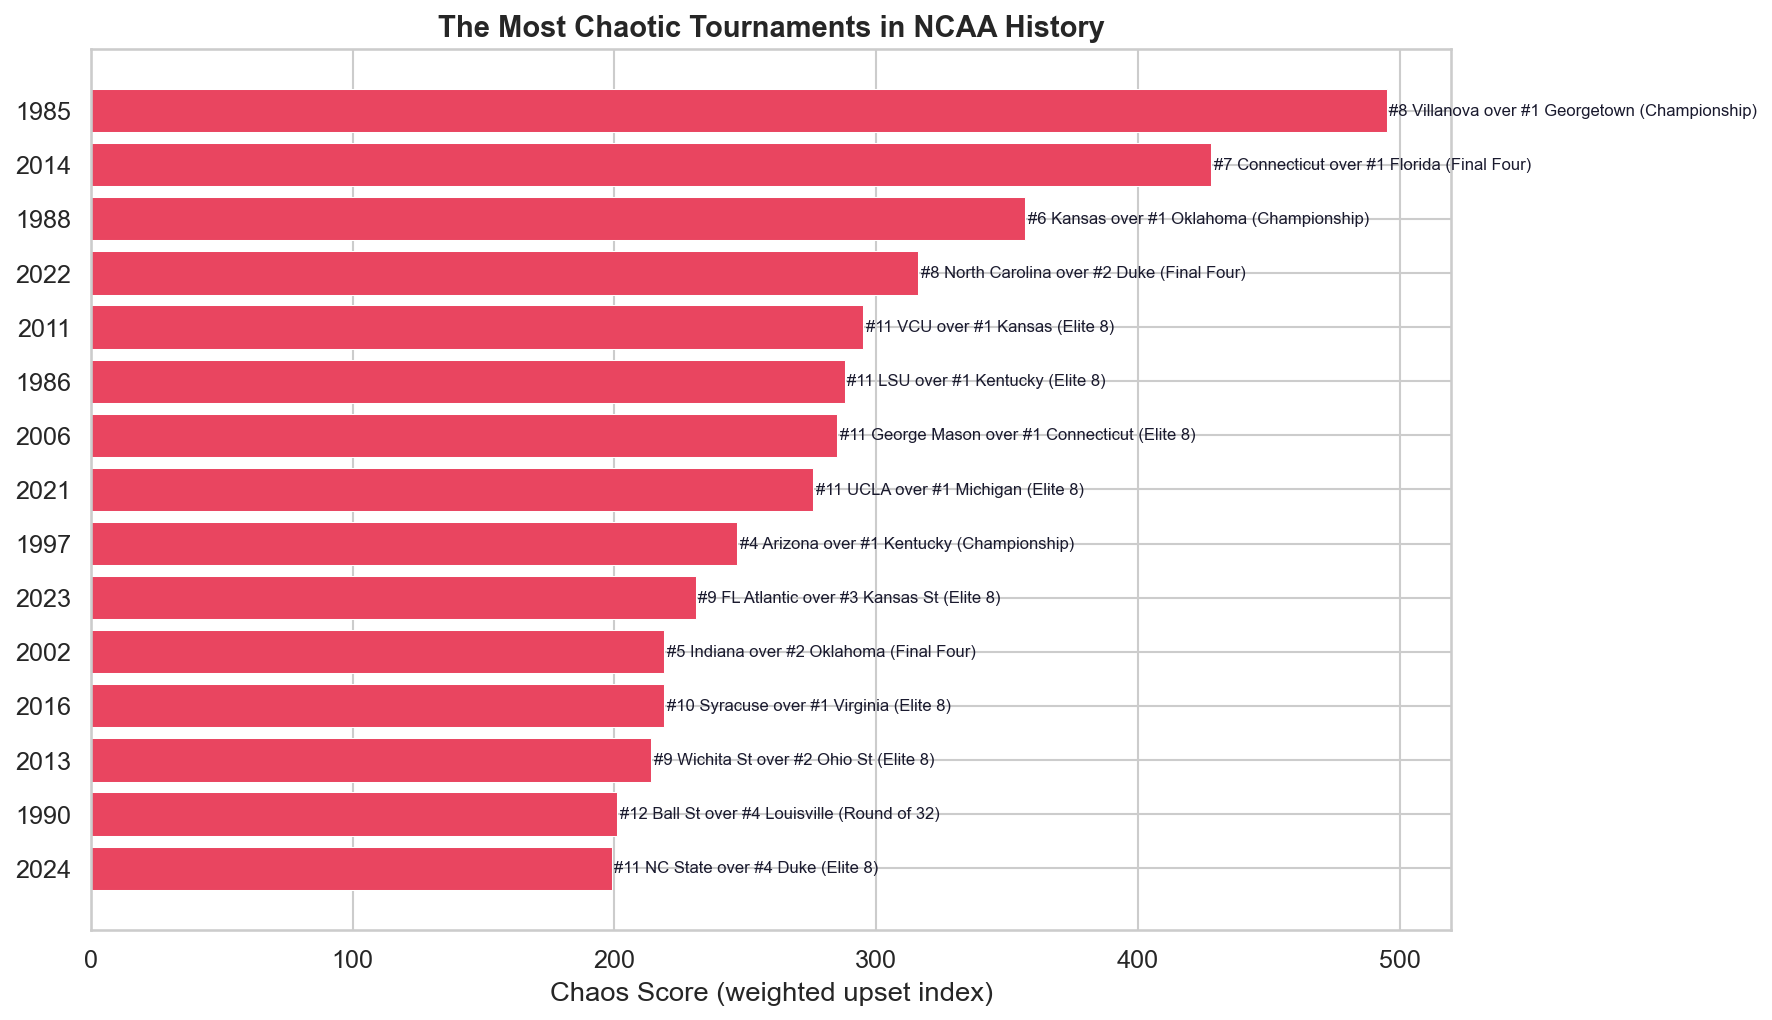

In [11]:
top_n = 15
top_chaos = chaos.head(top_n).sort_values("ChaosScore")

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_chaos["Season"].astype(str),
    top_chaos["ChaosScore"],
    color=COLORS["accent"],
    edgecolor="white",
    linewidth=0.5,
)

# Annotate with biggest upset
for bar, upset in zip(bars, top_chaos["BiggestUpset"]):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        upset,
        va="center",
        fontsize=8,
        color=COLORS["primary"],
    )

ax.set_xlabel("Chaos Score (weighted upset index)")
ax.set_title(
    "The Most Chaotic Tournaments in NCAA History",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/act1_chaos_rankings.png")
plt.show()

---
## 6. Seed Survival Heatmap: How Far Does Each Seed Actually Go?

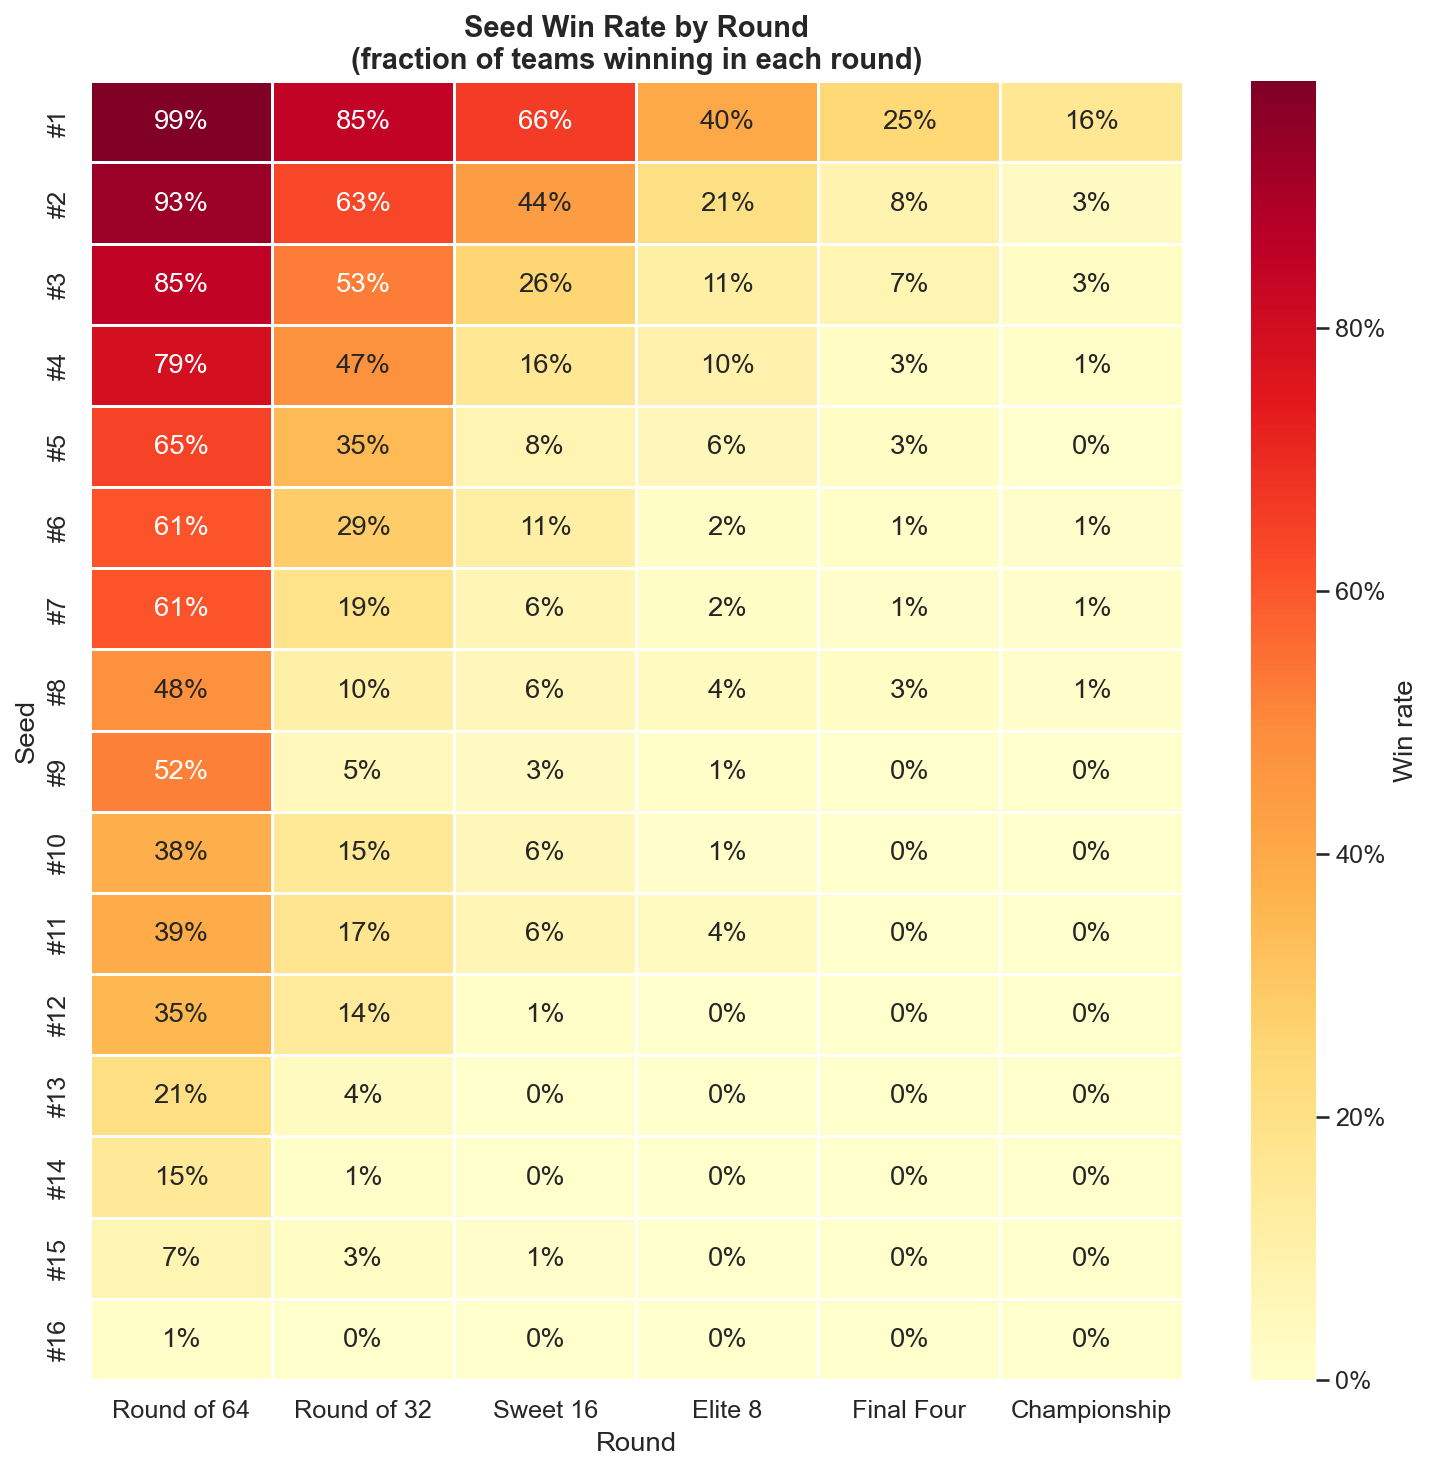

In [12]:
advancement = seed_advancement_rates(games)

fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(
    advancement,
    annot=True,
    fmt=".0%",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    xticklabels=[ROUND_NAMES.get(c, c) for c in advancement.columns],
    yticklabels=[f"#{i}" for i in advancement.index],
    cbar_kws={"label": "Win rate", "format": mtick.PercentFormatter(1.0)},
)

ax.set_ylabel("Seed")
ax.set_xlabel("Round")
ax.set_title(
    "Seed Win Rate by Round\n(fraction of teams winning in each round)",
    fontsize=14,
    fontweight="bold",
)

plt.tight_layout()
fig.savefig(f"{FIGURES_DIR}/act1_seed_survival_heatmap.png")
plt.show()

**Takeaway:** The heatmap tells the whole story at a glance. **Seeds 1-4 own the tournament** — they account for nearly all Sweet 16, Elite 8, and Final Four wins. Seeds 5-8 can win their first game but rarely survive the second weekend. Seeds 9-16 are essentially tourists past Round 1 — with rare, glorious exceptions that make March Madness what it is.

---

## Summary: Key Numbers from the Autopsy

In [13]:
# Summary stats (excluding play-in games)
main_bracket = games[games["Round"] > 0]
total_upsets = main_bracket["Upset"].sum()
total_games = len(main_bracket)
overall_upset_rate = total_upsets / total_games

print(f"Main bracket games (1985–present): {total_games}")
print(f"Total upsets: {int(total_upsets)} ({overall_upset_rate:.1%})")
print(f"Seasons covered: {main_bracket['Season'].min()}–{main_bracket['Season'].max()}")
print(f"\nMost chaotic tournament: {int(chaos.iloc[0]['Season'])} (chaos score: {chaos.iloc[0]['ChaosScore']:.0f})")
print(f"Biggest single upset: {chaos.iloc[0]['BiggestUpset']}")
print(f"\nDeadliest round by upset rate: Elite 8 ({upset_rate_by_round(games).set_index('Round').loc[4, 'UpsetRate']:.1%})")
print(f"Biggest trap matchup: #8 vs #9 ({upset_rate_by_matchup(games).set_index('Matchup').loc['#8 vs #9', 'UpsetRate']:.1%} upset rate)")

Main bracket games (1985–present): 2456
Total upsets: 695 (28.3%)
Seasons covered: 1985–2024

Most chaotic tournament: 1985 (chaos score: 495)
Biggest single upset: #8 Villanova over #1 Georgetown (Championship)

Deadliest round by upset rate: Elite 8 (43.6%)
Biggest trap matchup: #8 vs #9 (51.9% upset rate)
